# Notebook 1 — k-Space Basics & Zero-Filled Reconstruction

Build intuition for k-space, undersampling masks, and the zero-filled baseline.

- The MRI forward model: `y = M · F · x` (masked Fourier encoding)
- Orthonormal FFT convention (`norm="ortho"`) for unit-norm operators
- Cartesian undersampling with a fully-sampled low-frequency center band
- Zero-filled reconstruction as the adjoint: `x_zf = F^H · M · y`

Masks are generated in the *unshifted* FFT domain
where DC (zero frequency) is at index 0. The center band wraps around index 0,
covering columns `0..c-1` and `N-c..N-1`.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from skimage.metrics import structural_similarity as ssim

np.random.seed(42)


plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "white",
})

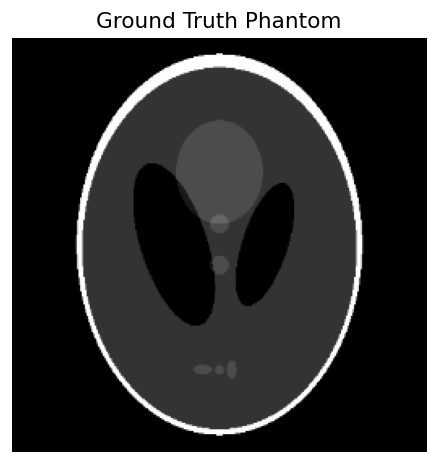

Shape: (256, 256), Range: [0.000, 1.000]


In [25]:
# load Shepp-Logan phantom
image = shepp_logan_phantom()
image = resize(image, (256, 256), anti_aliasing=True).astype(np.float32)
N = image.shape[0]

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(image, cmap="gray")
ax.set_title("Ground Truth Phantom")
ax.axis("off")
plt.tight_layout()
plt.show()
print(f"Shape: {image.shape}, Range: [{image.min():.3f}, {image.max():.3f}]")

## k-Space: The Fourier Transform of the Image

MRI acquires data in the spatial-frequency domain (k-space). We use `norm="ortho"`
throughout this project so that `F` and `F^H` are both unitary — this keeps
operator norms at 1 and simplifies step-size selection in optimization.

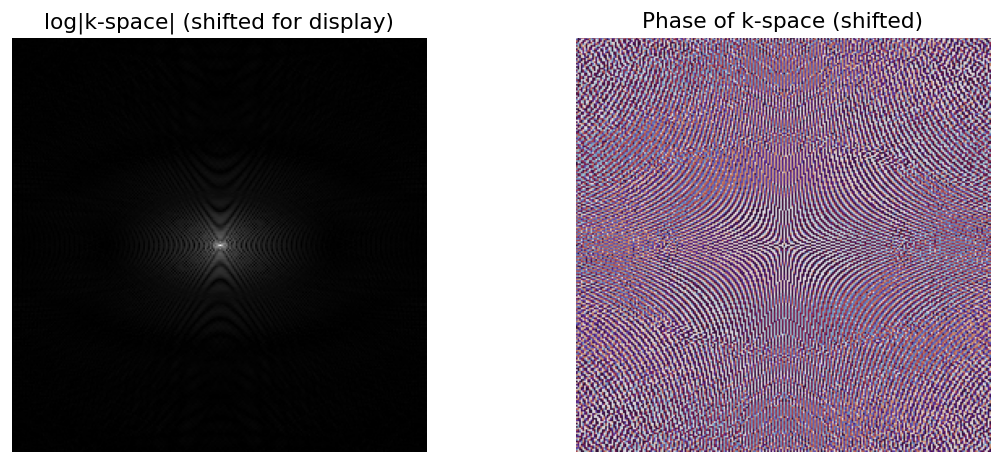

In [26]:
# Full k-space with orthonormal FFT
kspace_full = np.fft.fft2(image, norm="ortho")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(np.log1p(np.abs(np.fft.fftshift(kspace_full))), cmap="gray")
axes[0].set_title("log|k-space| (shifted for display)")
axes[0].axis("off")

axes[1].imshow(np.angle(np.fft.fftshift(kspace_full)), cmap="twilight", vmin=-np.pi, vmax=np.pi)
axes[1].set_title("Phase of k-space (shifted)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [27]:
# sanity check, full-mask round-trip should be identity
recon_full = np.fft.ifft2(kspace_full, norm="ortho")
print(f"Round-trip max |error|: {np.max(np.abs(recon_full.real - image)):.2e}")
assert np.max(np.abs(recon_full.real - image)) < 1e-5, "FFT round-trip failed!"
print("FFT round-trip: PASS")

Round-trip max |error|: 2.38e-07
FFT round-trip: PASS


## Undersampling Masks

The mask must live in the same domain as the unshifted FFT output.
In NumPy's `fft2` output, DC is at index (0, 0) and the Nyquist frequency is
at index (N//2, N//2). The "center band" of low frequencies wraps around index 0:
columns `{0, 1, ..., c-1}` and `{N-c, ..., N-1}`.

For *display*, we `fftshift` the mask so it looks like the conventional view
with DC in the center.

In [28]:
def make_cartesian_mask(N, R, center_frac=0.08):
    """Uniform Cartesian undersampling mask (unshifted FFT convention).

    Keeps every R-th phase-encode column plus a fully-sampled center band
    of width `center_frac * N` centered on DC (index 0, wrapping).

    Parameters
    ----------
    N : int — image/k-space size (assumes square)
    R : int — acceleration factor (keep every R-th column)
    center_frac : float — fraction of columns in the fully-sampled center band

    Returns
    -------
    mask : (N, N) float32 binary mask in unshifted FFT convention
    """
    mask = np.zeros((N, N), dtype=np.float32)
    mask[:, ::R] = 1.0
    c = max(1, int((center_frac * N) / 2))
    # low-freq center wraps around index 0 in unshifted convention
    mask[:, :c] = 1.0
    mask[:, N - c:] = 1.0
    return mask


def random_cartesian_mask(N, accel=4, center_frac=0.08, rng=None):
    """Random Cartesian undersampling mask (unshifted FFT convention).

    Selects ~N/accel phase-encode columns randomly, always including a
    fully-sampled low-frequency center band around DC (index 0).

    Parameters
    ----------
    N : int — image/k-space size (assumes square)
    accel : int — nominal acceleration factor
    center_frac : float — fraction of columns in the center band
    rng : np.random.Generator or None

    Returns
    -------
    mask : (N, N) float32 binary mask in unshifted FFT convention
    """
    if rng is None:
        rng = np.random.default_rng()
    mask = np.zeros((N, N), dtype=np.float32)
    c = max(1, int((center_frac * N) / 2))
    center_cols = np.concatenate([np.arange(0, c), np.arange(N - c, N)])
    num_cols = max(len(center_cols), N // accel)
    remaining = num_cols - len(center_cols)
    candidates = np.setdiff1d(np.arange(N), center_cols)
    if remaining > 0:
        pick = rng.choice(candidates, size=remaining, replace=False)
        cols = np.concatenate([center_cols, pick])
    else:
        cols = center_cols
    mask[:, cols] = 1.0
    return mask


def effective_acceleration(mask):
    """Compute the actual acceleration factor from a binary mask."""
    return mask.shape[1] / np.sum(mask[0, :])

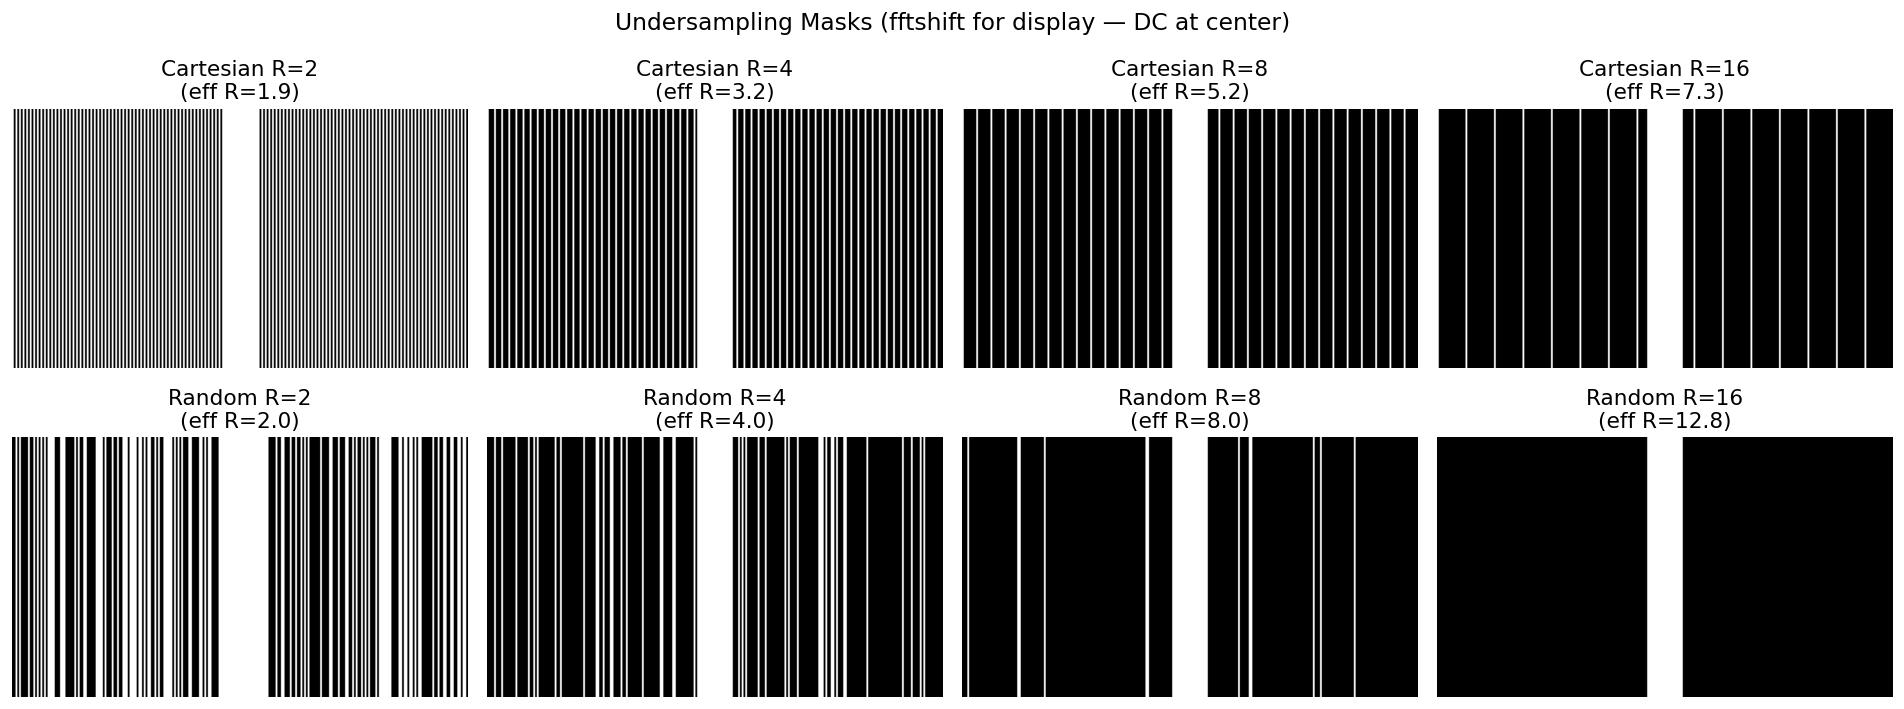

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
rng = np.random.default_rng(0)

for i, R in enumerate([2, 4, 8, 16]):
    m_cart = make_cartesian_mask(N, R, center_frac=0.08)
    m_rand = random_cartesian_mask(N, accel=R, center_frac=0.08, rng=rng)

    # display in shifted convention (DC at center) for visual clarity
    axes[0, i].imshow(np.fft.fftshift(m_cart), cmap="gray", aspect="auto")
    axes[0, i].set_title(f"Cartesian R={R}\n(eff R={effective_acceleration(m_cart):.1f})")
    axes[0, i].axis("off")

    axes[1, i].imshow(np.fft.fftshift(m_rand), cmap="gray", aspect="auto")
    axes[1, i].set_title(f"Random R={R}\n(eff R={effective_acceleration(m_rand):.1f})")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Cartesian", fontsize=12)
axes[1, 0].set_ylabel("Random", fontsize=12)
fig.suptitle("Undersampling Masks (fftshift for display — DC at center)", fontsize=14)
plt.tight_layout()
plt.show()

## Forward Model & Zero-Filled Reconstruction

The forward model is `y = M · F · x` where:
- `F` = orthonormal 2D FFT (`norm="ortho"`)
- `M` = binary undersampling mask
- `x` = ground truth image

The zero-filled reconstruction is the adjoint: `x_zf = F^H · M · y`.
With `norm="ortho"`, this is also the pseudo-inverse restricted to sampled frequencies.

In [30]:
def A_forward(x, mask):
    """Forward model: y = M * F(x) with ortho FFT."""
    return mask * np.fft.fft2(x, norm="ortho")

def A_adjoint(y, mask):
    """Adjoint: x = F^H(M * y) with ortho FFT."""
    return np.fft.ifft2(mask * y, norm="ortho")

def zero_fill(x_gt, mask):
    """Zero-filled reconstruction pipeline."""
    y = A_forward(x_gt, mask)
    return np.real(A_adjoint(y, mask))

In [31]:
def compute_psnr(recon, truth, data_range=None):
    """Standard PSNR. data_range defaults to max(truth) - min(truth)."""
    if data_range is None:
        data_range = float(truth.max() - truth.min())
    mse = np.mean((recon - truth) ** 2)
    if mse < 1e-15:
        return float("inf")
    return 20.0 * np.log10(data_range / np.sqrt(mse))

def compute_ssim(recon, truth, data_range=None):
    """SSIM via skimage."""
    if data_range is None:
        data_range = float(truth.max() - truth.min())
    return ssim(recon, truth, data_range=data_range)

def compute_nmse(recon, truth):
    """Normalized MSE: ||recon - truth||^2 / ||truth||^2."""
    return float(np.sum((recon - truth) ** 2) / (np.sum(truth ** 2) + 1e-12))

R= 2 | eff_R=2.0 | PSNR=21.65 dB | SSIM=0.3726 | NMSE=0.116233
R= 4 | eff_R=4.0 | PSNR=19.42 dB | SSIM=0.4305 | NMSE=0.194470
R= 8 | eff_R=8.0 | PSNR=18.84 dB | SSIM=0.4608 | NMSE=0.222217
R=16 | eff_R=12.8 | PSNR=18.39 dB | SSIM=0.4733 | NMSE=0.246220


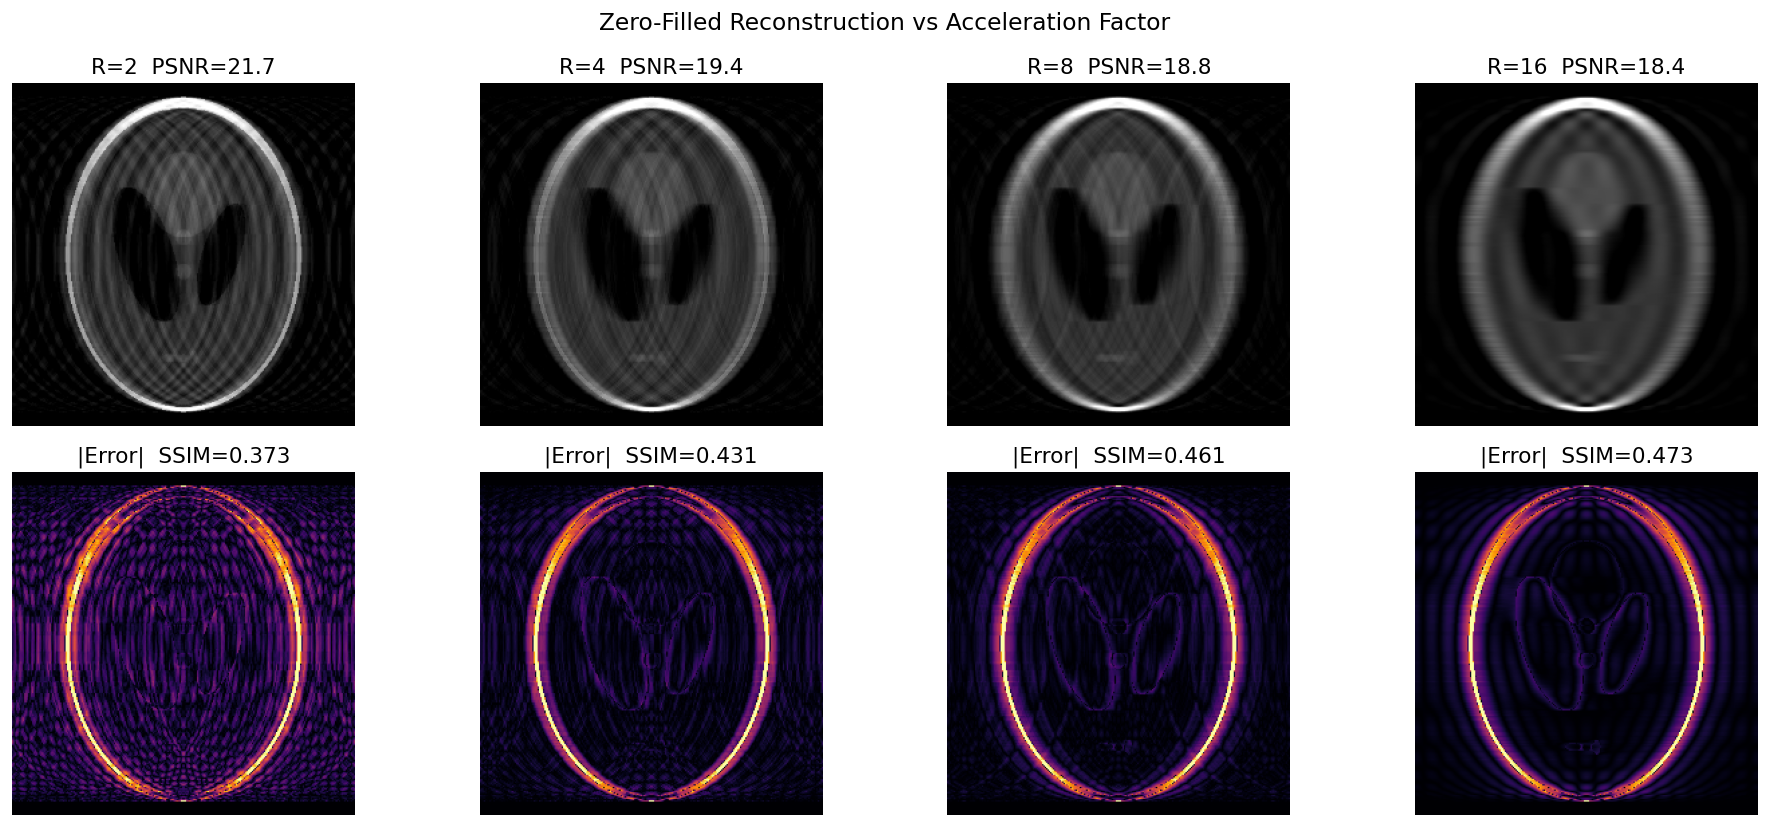

In [32]:
# zero-fill reconstructions across acceleration factors
rng = np.random.default_rng(123)
Rs = [2, 4, 8, 16]

fig, axes = plt.subplots(2, len(Rs), figsize=(16, 7))

for i, R in enumerate(Rs):
    mask = random_cartesian_mask(N, accel=R, center_frac=0.08, rng=rng)
    recon = zero_fill(image, mask)

    p = compute_psnr(recon, image)
    s = compute_ssim(recon, image)

    axes[0, i].imshow(recon, cmap="gray", vmin=image.min(), vmax=image.max())
    axes[0, i].set_title(f"R={R}  PSNR={p:.1f}")
    axes[0, i].axis("off")

    err = np.abs(recon - image)
    axes[1, i].imshow(err, cmap="inferno", vmin=0, vmax=np.quantile(err, 0.99))
    axes[1, i].set_title(f"|Error|  SSIM={s:.3f}")
    axes[1, i].axis("off")

    print(f"R={R:2d} | eff_R={effective_acceleration(mask):.1f} | "
          f"PSNR={p:.2f} dB | SSIM={s:.4f} | NMSE={compute_nmse(recon, image):.6f}")

fig.suptitle("Zero-Filled Reconstruction vs Acceleration Factor", fontsize=14)
plt.tight_layout()
plt.show()

## Center Band Matters: With vs Without

The fully-sampled center band preserves bulk contrast (low-frequency content).
Without it, even moderate acceleration produces severe artifacts.

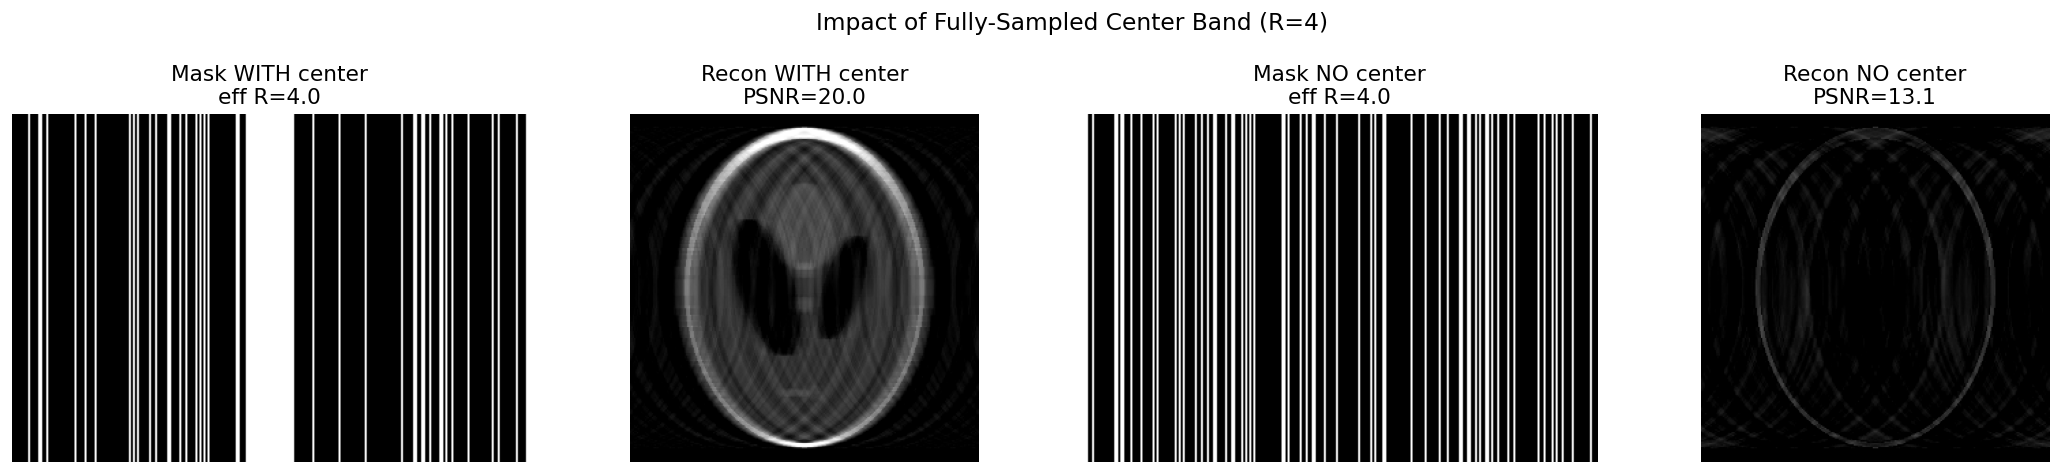

In [33]:

rng1 = np.random.default_rng(99)
rng2 = np.random.default_rng(99)    # same seed for same random columns

R = 4
mask_with_center = random_cartesian_mask(N, accel=R, center_frac=0.10, rng=rng1)
# mask WITHOUT center: just random columns, no guaranteed low-freq band
mask_no_center = np.zeros((N, N), dtype=np.float32)
num_cols = N // R
cols = rng2.choice(N, size=num_cols, replace=False)
mask_no_center[:, cols] = 1.0

recon_with = zero_fill(image, mask_with_center)
recon_without = zero_fill(image, mask_no_center)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(np.fft.fftshift(mask_with_center), cmap="gray", aspect="auto")
axes[0].set_title(f"Mask WITH center\neff R={effective_acceleration(mask_with_center):.1f}")
axes[0].axis("off")

axes[1].imshow(recon_with, cmap="gray", vmin=image.min(), vmax=image.max())
axes[1].set_title(f"Recon WITH center\nPSNR={compute_psnr(recon_with, image):.1f}")
axes[1].axis("off")

axes[2].imshow(np.fft.fftshift(mask_no_center), cmap="gray", aspect="auto")
axes[2].set_title(f"Mask NO center\neff R={effective_acceleration(mask_no_center):.1f}")
axes[2].axis("off")

axes[3].imshow(recon_without, cmap="gray", vmin=image.min(), vmax=image.max())
axes[3].set_title(f"Recon NO center\nPSNR={compute_psnr(recon_without, image):.1f}")
axes[3].axis("off")

plt.suptitle("Impact of Fully-Sampled Center Band (R=4)", fontsize=14)
plt.tight_layout()
plt.show()

## Publication-Quality Summary Figure

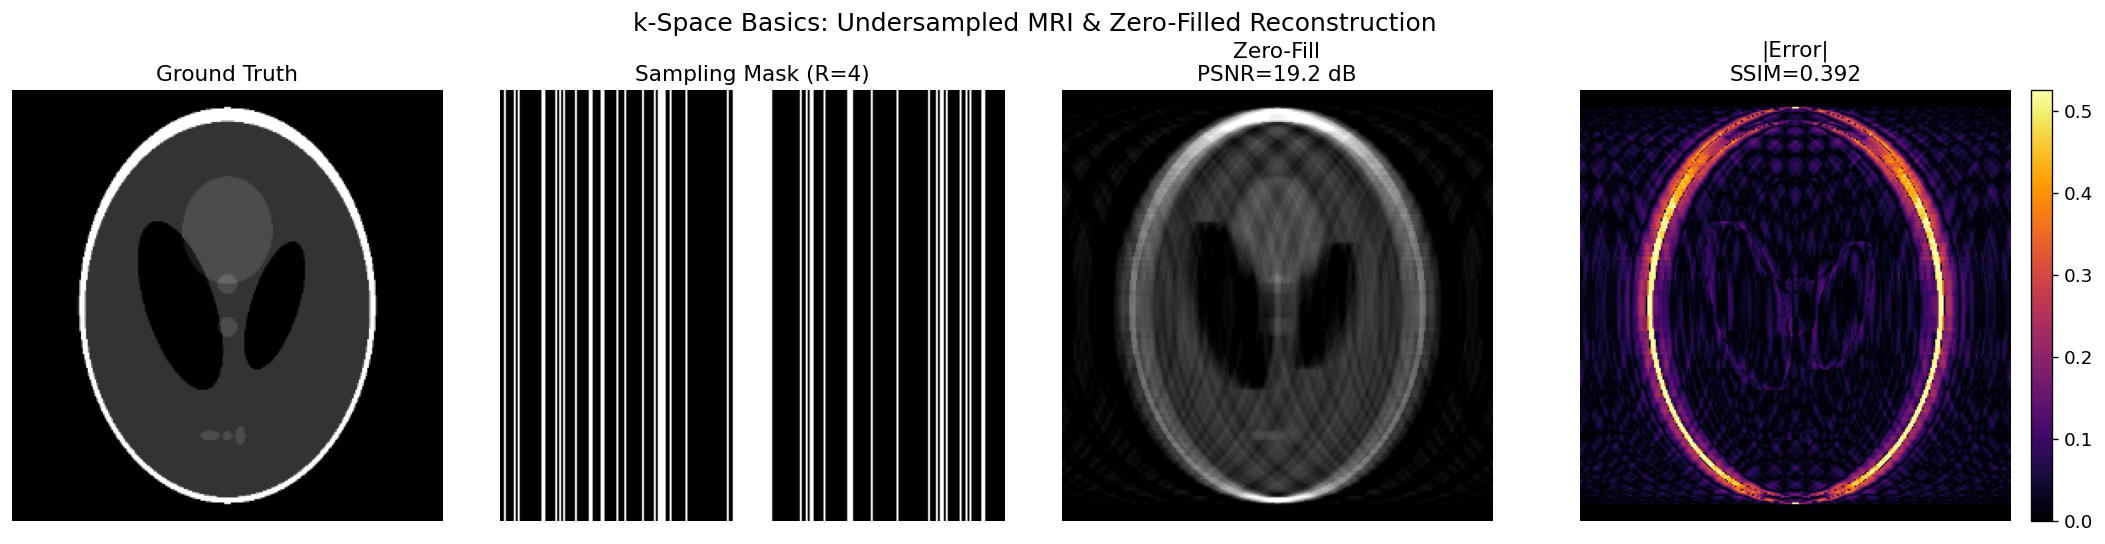

In [34]:
# summary figure: Original + k-space + zero-fill + error
R = 4
rng = np.random.default_rng(42)
mask = random_cartesian_mask(N, accel=R, center_frac=0.08, rng=rng)
y = A_forward(image, mask)
recon = zero_fill(image, mask)
err = np.abs(recon - image)

kspace_vis = np.log1p(np.abs(np.fft.fftshift(y)))

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Ground Truth")
axes[0].axis("off")

axes[1].imshow(np.fft.fftshift(mask), cmap="gray", aspect="auto")
axes[1].set_title(f"Sampling Mask (R={R})")
axes[1].axis("off")

axes[2].imshow(recon, cmap="gray", vmin=image.min(), vmax=image.max())
axes[2].set_title(f"Zero-Fill\nPSNR={compute_psnr(recon, image):.1f} dB")
axes[2].axis("off")

im = axes[3].imshow(err, cmap="inferno", vmin=0, vmax=np.quantile(err, 0.99))
axes[3].set_title(f"|Error|\nSSIM={compute_ssim(recon, image):.3f}")
axes[3].axis("off")
fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

fig.suptitle("k-Space Basics: Undersampled MRI & Zero-Filled Reconstruction", fontsize=15)
plt.tight_layout()
plt.show()